# Qwen-VL Training Visualization

This notebook visualizes training metrics from `train_metrics.jsonl` and `val_metrics.jsonl`.

In [8]:
import json
import os
import matplotlib.pyplot as plt

def load_jsonl(filepath):
    """Load metrics from jsonl file."""
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return []
    metrics = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                metrics.append(json.loads(line))
    return metrics

In [9]:
# Configuration
EXP_NAME = "lora_bs2_acc4_epo1_val100"  # Change this to your experiment name
SAVE_DIR = "./outputs"

EXP_DIR = os.path.join(SAVE_DIR, EXP_NAME)
LOG_DIR = os.path.join(EXP_DIR, "log")
PLT_DIR = os.path.join(EXP_DIR, "plt_fig")

os.makedirs(PLT_DIR, exist_ok=True)

train_metrics_path = os.path.join(LOG_DIR, "train_metrics.jsonl")
val_metrics_path = os.path.join(LOG_DIR, "val_metrics.jsonl")

In [10]:
# Load metrics
train_metrics = load_jsonl(train_metrics_path)
val_metrics = load_jsonl(val_metrics_path)

print(f"Loaded {len(train_metrics)} train metric records")
print(f"Loaded {len(val_metrics)} val metric records")

Loaded 11967 train metric records
Loaded 23 val metric records


In [11]:
# Extract training loss
if train_metrics:
    # Use same filter for all metrics to ensure same length
    valid_metrics = [m for m in train_metrics if 'step' in m and 'loss' in m]
    train_steps = [m['step'] for m in valid_metrics]
    train_losses = [m['loss'] for m in valid_metrics]
    train_grad_norms = [m.get('grad_norm') for m in valid_metrics]
    train_lrs = [m.get('learning_rate', 0) for m in valid_metrics]
    print(f"Train steps: {len(train_steps)}")
    print(f"First train loss: {train_losses[0] if train_losses else 'N/A'}")
    print(f"Last train loss: {train_losses[-1] if train_losses else 'N/A'}")

Train steps: 11966
First train loss: 0.04887548089027405
Last train loss: 2.775614404981752e-07


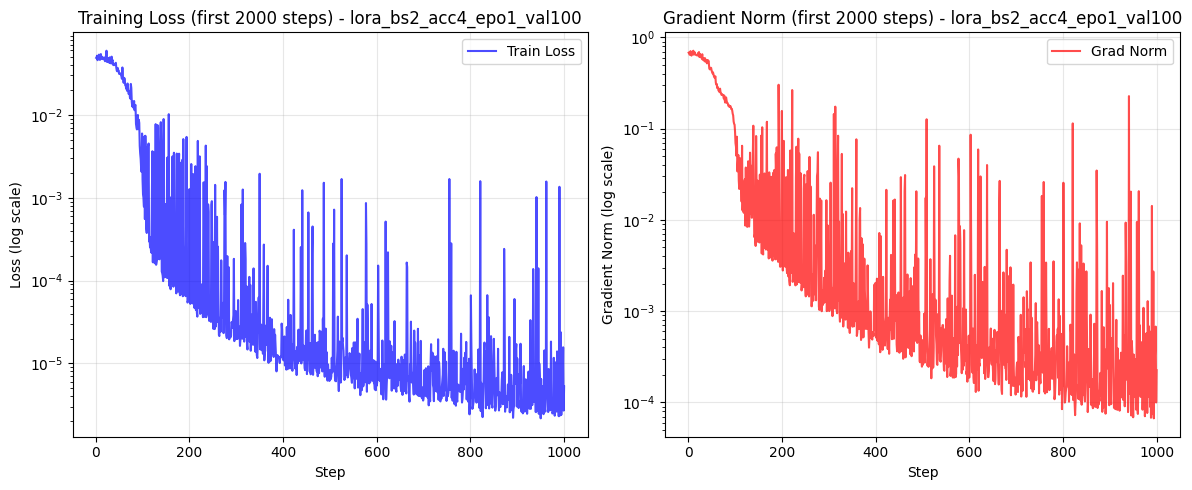

Train curve saved to: ./outputs/lora_bs2_acc4_epo1_val100/plt_fig/train_curve.png


In [18]:
# Plot training loss (first 2000 steps, log scale)
if train_steps:
    # Filter to first 2000 steps
    idx = [i for i, s in enumerate(train_steps) if s <= 1000]
    steps_2k = [train_steps[i] for i in idx]
    losses_2k = [train_losses[i] for i in idx]
    grads_2k = [train_grad_norms[i] for i in idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Loss curve (log scale)
    axes[0].plot(steps_2k, losses_2k, 'b-', alpha=0.7, label='Train Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss (log scale)')
    axes[0].set_title(f'Training Loss (first 2000 steps) - {EXP_NAME}')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Gradient norm (log scale)
    if grads_2k:
        axes[1].plot(steps_2k, grads_2k, 'r-', alpha=0.7, label='Grad Norm')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Gradient Norm (log scale)')
        axes[1].set_title(f'Gradient Norm (first 2000 steps) - {EXP_NAME}')
        axes[1].set_yscale('log')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
    
    plt.tight_layout()
    
    loss_curve_path = os.path.join(PLT_DIR, "train_curve.png")
    plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Train curve saved to: {loss_curve_path}")

In [13]:
# Extract validation metrics
if val_metrics:
    val_steps = [m['step'] for m in val_metrics if 'step' in m]
    val_srcc = [m.get('srcc', 0) for m in val_metrics if 'step' in m]
    val_plcc = [m.get('plcc', 0) for m in val_metrics if 'step' in m]
    val_level_acc = [m.get('level_acc', 0) for m in val_metrics if 'step' in m]
    print(f"Val steps: {len(val_steps)}")
    if val_srcc:
        print(f"First SRCC: {val_srcc[0]:.4f}")
        print(f"Last SRCC: {val_srcc[-1]:.4f}")

Val steps: 23
First SRCC: 0.2795
Last SRCC: 0.2174


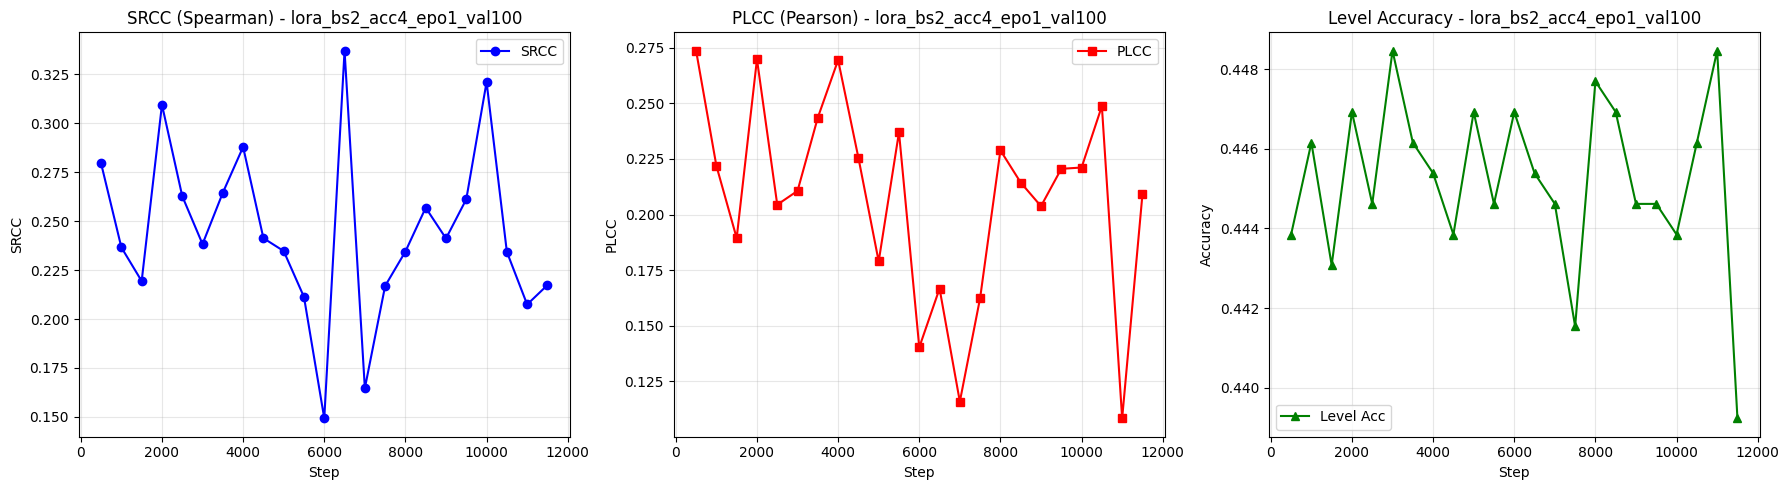

Val metrics curve saved to: ./outputs/lora_bs2_acc4_epo1_val100/plt_fig/val_metrics_curve.png


In [14]:
# Plot validation metrics
if val_steps:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # SRCC
    axes[0].plot(val_steps, val_srcc, 'b-', marker='o', label='SRCC')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('SRCC')
    axes[0].set_title(f'SRCC (Spearman) - {EXP_NAME}')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # PLCC
    axes[1].plot(val_steps, val_plcc, 'r-', marker='s', label='PLCC')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('PLCC')
    axes[1].set_title(f'PLCC (Pearson) - {EXP_NAME}')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Level Accuracy
    axes[2].plot(val_steps, val_level_acc, 'g-', marker='^', label='Level Acc')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title(f'Level Accuracy - {EXP_NAME}')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    
    val_curve_path = os.path.join(PLT_DIR, "val_metrics_curve.png")
    plt.savefig(val_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Val metrics curve saved to: {val_curve_path}")

In [ ]:
print("Visualization complete!")
print(f"Output directory: {PLT_DIR}")